# Model Experimentation

The metric that we will look at is the recall score. Accuracy will not be an adequate enough metric to measure the performance of the models since the need to classify the people who are NOT satisfied is equally as important as classifying the customers that ARE satisfied. So as we look at the performance metrics throughout this notebook, note how the recall for both classes performs on the models that are being trained and evaluated.

In [1]:
%%capture
%pip install lazypredict hyperopt ipywidgets

In [2]:
from lazypredict.Supervised import LazyClassifier
import hyperopt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action='ignore')

In [115]:
df = pd.read_csv('data/ACME-HappinessSurvey2020.csv')

columns = [
            # 'customer satisfaction',
              'my order was delivered on time', 
              'contents of my order was as I expected',
              'I ordered everything I wanted to order',
              'I paid good price for my order',
              'I am satisfied with my courier',
              'the app makes ordering easy'
              ]

df.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [4]:
target_variable = df['Y']
X = df.drop(columns=['Y'], axis=1)

X.head()

,X1,X2,X3,X4,X5,X6
0,3,3,3,4,2,4
1,3,2,3,5,4,3
2,5,3,3,3,3,5
3,5,4,3,3,3,5
4,5,4,3,3,3,5


In [6]:
import random
import ipywidgets
from ipywidgets import IntProgress

# seed = random.randint(1000, 9999)
seed = 4213
print(seed)

X_train, X_test, y_train, y_test = train_test_split(X, target_variable, test_size=.20, random_state=seed)

classifiers = LazyClassifier(verbose=0, ignore_warnings=True, random_state=seed, custom_metric=None)

models, preds = classifiers.fit(X_train, X_test, y_train, y_test)
models

4213


  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 56, number of negative: 44
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31
[LightGBM] [Info] Number of data points in the train set: 100, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.560000 -> initscore=0.241162
[LightGBM] [Info] Start training from score 0.241162
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LGBMClassifier,0.73,0.73,0.73,0.72,0.03
GaussianNB,0.69,0.69,0.69,0.68,0.00
RidgeClassifierCV,0.69,0.69,0.69,0.68,0.01
RidgeClassifier,0.69,0.69,0.69,0.68,0.01
NearestCentroid,0.69,0.69,0.69,0.68,0.00
LogisticRegression,0.69,0.69,0.69,0.68,0.00
LinearDiscriminantAnalysis,0.69,0.69,0.69,0.68,0.00
LinearSVC,0.69,0.69,0.69,0.68,0.00
AdaBoostClassifier,0.65,0.65,0.65,0.64,0.05


In [7]:
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [8]:
print(f'Shape of training dataset:\n\t{X_train.shape, y_train.shape}')
print(f'Shape of testing dataset:\n\t{X_test.shape, y_test.shape}')

Shape of training dataset:
	((100, 6), (100,))
Shape of testing dataset:
	((26, 6), (26,))


In [9]:
models_dict = {
    'Logistic Regression': LogisticRegression(random_state=seed),
    # 'Bernoulli Naive-Bayes': BernoulliNB(),
    'SVC': SVC(random_state=seed),
    'LinearSVC': LinearSVC(random_state=seed),
    'XGBoost': XGBClassifier(),
    'KNeighbors Classifer': KNeighborsClassifier(),
    'GaussianNB': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=seed)
}

In [10]:
#### base model predictions

for name, model in models_dict.items():
    print(f"{'*'*30} {name} {'*'*30}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f'Training score: {train_score:.5f}')
    print(f'Testing score: {test_score:.5f}')
    # print(f'Cross validation scores: {cross_val_score(model, X_train, y_train)}')
    print(f"Classification report:\n{classification_report(y_test, y_pred)}\n")
    # print(confusion_matrix(y_test, y_pred))

****************************** Logistic Regression ******************************
Training score: 0.60000
Testing score: 0.69231
Classification report:
              precision    recall  f1-score   support

           0       0.86      0.46      0.60        13
           1       0.63      0.92      0.75        13

    accuracy                           0.69        26
   macro avg       0.74      0.69      0.68        26
weighted avg       0.74      0.69      0.68        26


****************************** SVC ******************************
Training score: 0.75000
Testing score: 0.61538
Classification report:
              precision    recall  f1-score   support

           0       0.80      0.31      0.44        13
           1       0.57      0.92      0.71        13

    accuracy                           0.62        26
   macro avg       0.69      0.62      0.58        26
weighted avg       0.69      0.62      0.58        26


****************************** LinearSVC ***************

## Hyperparameter Tuning

In [11]:
## HELPER FUNCTIONS FOR RANDOMIZED and EXHAUSTIVE GRID SEARCH and ROC PLOTTING

def random_search(estimator, params, X_train, y_train, X_test, y_test, random_state, cv=5, n_jobs=-1):
    estimator.random_state = random_state
    model_cv = RandomizedSearchCV(estimator=estimator,
                                  param_distributions=params,
                                  cv=cv,
                                  n_jobs=n_jobs,
                                  random_state=random_state
                                  )
    
    model_cv.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('*'*30, 'Randomized Search', '*'*30)
    print(f'Best parameters: \n\t{model_cv.best_params_}')
    print(f'Best score: \n\t{model_cv.best_score_:.4f}')
    print(f'Training Score: \n\t{model_cv.score(X_train, y_train):.4f}')
    print(f'Test score: \n\t{model_cv.score(X_test, y_test):.4f}')
    print(f"Classification report:\n{classification_report(y_test, y_pred)}")


def grid_search(estimator, params, X_train, y_train, X_test, y_test, random_state, n_jobs=-1, cv=5):
    estimator.random_state = random_state
    model_grid_search = GridSearchCV(estimator=estimator,
                                     param_grid=params,
                                     n_jobs=n_jobs,
                                     cv=cv
                                     )
    model_grid_search.fit(X_train, y_train)
    y_pred = model_grid_search.predict(X_test)
    print('*'*30, 'Grid Search', '*'*30)
    print(f'Best params: \n\t{model_grid_search.best_params_}')
    print(f'Best score: \n\t{model_grid_search.best_score_:.4f}')
    print(f'Training score: \n\t{model_grid_search.score(X_train, y_train):.4f}')
    print(f'Test score: \n\t{model_grid_search.score(X_test, y_test):.4f}')
    print(f"Classification report:\n{classification_report(y_test, y_pred)}")

def roc(y_proba, y_test):
    roc_score = roc_auc_score(y_test, y_proba)
    # print(roc_score)

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    x = np.linspace(0,1,100)
    y = x

    plt.plot(fpr, tpr, label=f'ROC Score: {roc_score:.4f}')
    plt.plot(x, y, '--', label='As Good As Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.title('True Positive Rate vs. False Positive Rate')
    plt.show()

In [12]:
#### Dictionary that will have the trained models as values

trained_models_dict = {}

### Linear SVC

In [13]:
svc_gauss_seed = 1882

X_train_gauss_svc, X_test_gauss_svc, y_train_gauss_svc, y_test_gauss_svc = train_test_split(X, target_variable, random_state=svc_gauss_seed, test_size=.20)
# print(X_train.shape, y_train.shape)

params = {
    'C': np.arange(1,1000,10)
    # 'C': np.logspace(-2.3, -1.3, 10)
}

random_search(estimator=models_dict['LinearSVC'], params=params, X_train=X_train_gauss_svc, y_train=y_train_gauss_svc, X_test=X_test_gauss_svc, y_test=y_test_gauss_svc, random_state=svc_gauss_seed)
grid_search(estimator=models_dict['LinearSVC'], params=params, X_train=X_train_gauss_svc, y_train=y_train_gauss_svc, X_test=X_test_gauss_svc, y_test=y_test_gauss_svc, random_state=svc_gauss_seed)

****************************** Randomized Search ******************************
Best parameters: 
	{'C': 491}
Best score: 
	0.5300
Training Score: 
	0.5400
Test score: 
	0.8077
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.94      1.00      0.97        16

    accuracy                           0.96        26
   macro avg       0.97      0.95      0.96        26
weighted avg       0.96      0.96      0.96        26

****************************** Grid Search ******************************
Best params: 
	{'C': 11}
Best score: 
	0.5300
Training score: 
	0.5400
Test score: 
	0.7692
Classification report:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.81      0.81      0.81        16

    accuracy                           0.77        26
   macro avg       0.76      0.76      0.76        26
weighted avg

In [14]:
linear_svc_model = LinearSVC(C=491, random_state=svc_gauss_seed)

linear_svc_model.fit(X_train_gauss_svc, y_train_gauss_svc)
y_pred = linear_svc_model.predict(X_test_gauss_svc)

print(f'LinearSVC Classification report:\n{classification_report(y_test_gauss_svc, y_pred)}')

trained_models_dict['Linear SVC'] = linear_svc_model

LinearSVC Classification report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.87      0.81      0.84        16

    accuracy                           0.81        26
   macro avg       0.80      0.81      0.80        26
weighted avg       0.81      0.81      0.81        26



### Gaussian Naive-Bayes

In [15]:
gauss_nb = GaussianNB()

gauss_nb.fit(X_train_gauss_svc, y_train_gauss_svc)
y_pred = gauss_nb.predict(X_test_gauss_svc)

gauss_probs = gauss_nb.predict_proba(X_test_gauss_svc)
gauss_probs = gauss_probs[:, 1]

print(classification_report(y_test_gauss_svc, y_pred))

trained_models_dict['gauss_nb'] = gauss_nb

              precision    recall  f1-score   support

           0       0.62      0.80      0.70        10
           1       0.85      0.69      0.76        16

    accuracy                           0.73        26
   macro avg       0.73      0.74      0.73        26
weighted avg       0.76      0.73      0.73        26



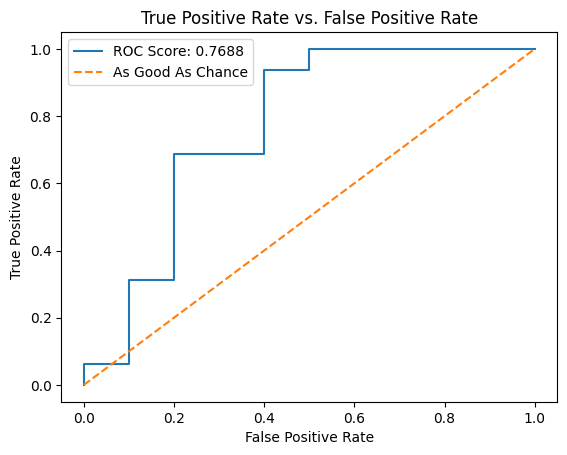

In [16]:
roc(y_proba=gauss_probs, y_test=y_test_gauss_svc)

### XGBoost

In [17]:
xgboost_seed = 1181

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X, target_variable, test_size=.20, random_state=xgboost_seed)

params = {
    'booster': ['gbtree', 'gblinear', 'dart']
}

random_search(estimator=models_dict['XGBoost'], params=params, X_train=X_train_xgb, y_train=y_train_xgb, X_test=X_test_xgb, y_test=y_test_xgb, random_state=xgboost_seed)
grid_search(estimator=models_dict['XGBoost'], params=params, X_train=X_train_xgb, y_train=y_train_xgb, X_test=X_test_xgb, y_test=y_test_xgb, random_state=xgboost_seed)

****************************** Randomized Search ******************************
Best parameters: 
	{'booster': 'gblinear'}
Best score: 
	0.5400
Training Score: 
	0.6200
Test score: 
	0.6154
Classification report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.94      0.97        16

    accuracy                           0.96        26
   macro avg       0.95      0.97      0.96        26
weighted avg       0.97      0.96      0.96        26

****************************** Grid Search ******************************
Best params: 
	{'booster': 'gblinear'}
Best score: 
	0.5400
Training score: 
	0.6200
Test score: 
	0.6154
Classification report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50        10
           1       0.69      0.69      0.69        16

    accuracy                           0.62        26
   macro avg       0.59      0.59      

In [18]:
params = {            ######### if the above grid searchs gave a 'booster' == 'gbtree' ############
    # 'booster': ['gbtree'],
    # 'eta': np.arange(0,1,.01),
    # 'gamma': np.arange(0,1000, 250),
    # 'max_depth': [6,8,10],
    # 'subsample': [.5]
}

params = {
    'booster': ['gblinear'],
    'reg_lambda': np.arange(.0001, 100, 10),
    'reg_alpha': np.arange(.0001, 100, 10) 
}

random_search(estimator=models_dict['XGBoost'], params=params, X_train=X_train_xgb, y_train=y_train_xgb, X_test=X_test_xgb, y_test=y_test_xgb, random_state=xgboost_seed)
grid_search(estimator=models_dict['XGBoost'], params=params, X_train=X_train_xgb, y_train=y_train_xgb, X_test=X_test_xgb, y_test=y_test_xgb, random_state=xgboost_seed)

****************************** Randomized Search ******************************
Best parameters: 
	{'reg_lambda': 60.0001, 'reg_alpha': 90.0001, 'booster': 'gblinear'}
Best score: 
	0.5300
Training Score: 
	0.5300
Test score: 
	0.6154
Classification report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.94      0.97        16

    accuracy                           0.96        26
   macro avg       0.95      0.97      0.96        26
weighted avg       0.97      0.96      0.96        26

****************************** Grid Search ******************************
Best params: 
	{'booster': 'gblinear', 'reg_alpha': 0.0001, 'reg_lambda': 0.0001}
Best score: 
	0.5400
Training score: 
	0.6200
Test score: 
	0.6154
Classification report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50        10
           1       0.69      0.69      0.69        16

    a

In [19]:
xgboost_model = XGBClassifier(booster='gblinear', reg_lambda=0.0001, reg_alpha=0.0001, random_state=xgboost_seed)
xgboost_model.fit(X_train_xgb, y_train_xgb)
y_pred = xgboost_model.predict(X_test_xgb)
xgboost_probs = xgboost_model.predict_proba(X_test_xgb)
xgboost_probs = xgboost_probs[:,1]

# print(xgboost_model.score(X_train_xgb, y_train_xgb))
# print(xgboost_model.score(X_test_xgb, y_test_xgb))
print(f"Classification report:\n{classification_report(y_test_xgb, y_pred)}")

trained_models_dict['XGBoost'] = xgboost_model

Classification report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50        10
           1       0.69      0.69      0.69        16

    accuracy                           0.62        26
   macro avg       0.59      0.59      0.59        26
weighted avg       0.62      0.62      0.62        26



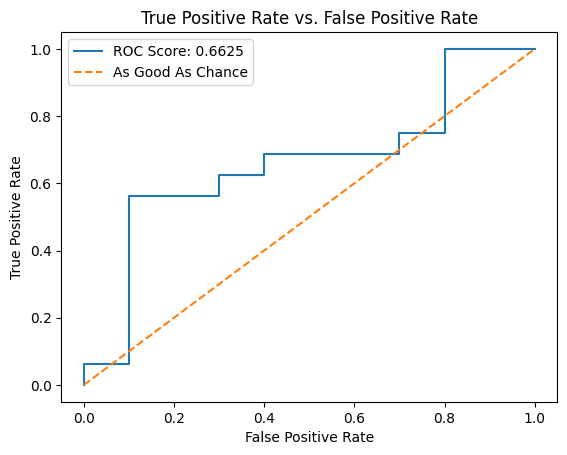

In [20]:
roc(y_proba=xgboost_probs, y_test=y_test_xgb)

### Random Forest

In [21]:
rf_seed = 4501

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, target_variable, random_state=rf_seed, test_size=.20)

params = {
    'n_estimators': np.arange(1,100,10),
    'max_features': ['sqrt'],
    'max_depth': [4,6,8],
    'min_samples_split': [2]
}

random_search(estimator=models_dict['Random Forest'], params=params, X_train=X_train_rf, y_train=y_train_rf, X_test=X_test_rf, y_test=y_test_rf, random_state=rf_seed)
grid_search(estimator=models_dict['Random Forest'], params=params, X_train=X_train_rf, y_train=y_train_rf, X_test=X_test_rf, y_test=y_test_rf, random_state=rf_seed)

****************************** Randomized Search ******************************
Best parameters: 
	{'n_estimators': 1, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 6}
Best score: 
	0.6000
Training Score: 
	0.7000
Test score: 
	0.5769
Classification report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        12
           1       0.87      0.93      0.90        14

    accuracy                           0.88        26
   macro avg       0.89      0.88      0.88        26
weighted avg       0.89      0.88      0.88        26

****************************** Grid Search ******************************
Best params: 
	{'max_depth': 6, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 1}
Best score: 
	0.6000
Training score: 
	0.7000
Test score: 
	0.5769
Classification report:
              precision    recall  f1-score   support

           0       0.53      0.67      0.59        12
           1       0.64     

In [22]:
rf_model = RandomForestClassifier(max_depth=6, max_features='sqrt', min_samples_split=2, n_estimators=1, random_state=rf_seed)

rf_model.fit(X_train_rf, y_train_rf)

y_preds = rf_model.predict(X_test_rf)
y_proba = rf_model.predict_proba(X_test_rf)

y_proba = y_proba[:, 1]

print(classification_report(y_test_rf, y_preds))

trained_models_dict['Random Forest'] = rf_model

              precision    recall  f1-score   support

           0       0.53      0.67      0.59        12
           1       0.64      0.50      0.56        14

    accuracy                           0.58        26
   macro avg       0.58      0.58      0.58        26
weighted avg       0.59      0.58      0.58        26



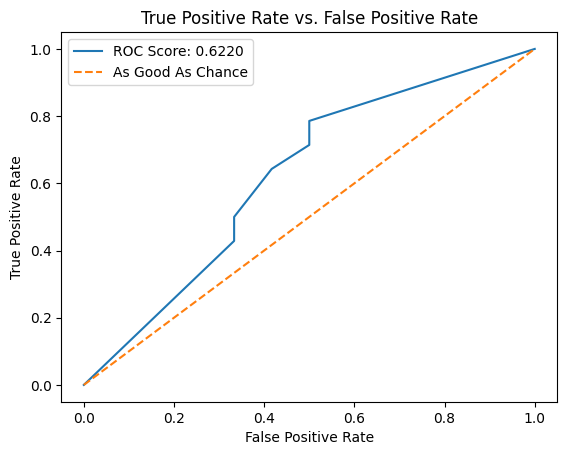

In [23]:
roc(y_proba=y_proba, y_test=y_test_rf)

## Voting Classifier

******************** Hard Voting ********************
              precision    recall  f1-score   support

           0       0.80      0.62      0.70        13
           1       0.69      0.85      0.76        13

    accuracy                           0.73        26
   macro avg       0.74      0.73      0.73        26
weighted avg       0.74      0.73      0.73        26

******************** Soft Voting w/ ROC score ********************
              precision    recall  f1-score   support

           0       0.67      0.46      0.55        13
           1       0.59      0.77      0.67        13

    accuracy                           0.62        26
   macro avg       0.63      0.62      0.61        26
weighted avg       0.63      0.62      0.61        26



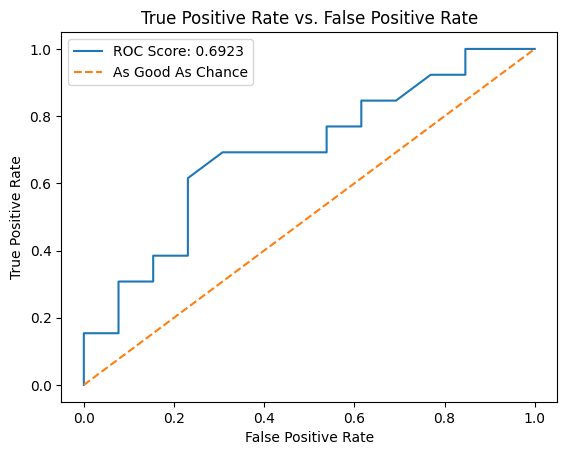

In [25]:
estimators = [
    ('LinearSVC', models_dict['LinearSVC']),
    ('GaussianNB', models_dict['GaussianNB']),
    ('XGBoost', models_dict['XGBoost']),
    ('Random Forest', models_dict['Random Forest'])
]

hard_vote_unfitted = VotingClassifier(estimators=estimators, voting='hard', n_jobs=-1)
soft_vote_unfitted = VotingClassifier(estimators=estimators[1:], voting='soft', n_jobs=-1)

hard_vote_unfitted.fit(X_train, y_train)
soft_vote_unfitted.fit(X_train, y_train)
hard_preds = hard_vote_unfitted.predict(X_test)
y_preds = soft_vote_unfitted.predict(X_test)
y_proba = soft_vote_unfitted.predict_proba(X_test)
y_proba = y_proba[:, 1]

print(f"{'*'*20} Hard Voting {'*'*20}")
print(classification_report(y_test, hard_preds))
print(f"{'*'*20} Soft Voting w/ ROC score {'*'*20}")
print(classification_report(y_test, y_preds))
roc(y_proba, y_test)

## Stacking Classifier

In [26]:
from sklearn.ensemble import StackingClassifier

stacking_class = StackingClassifier(estimators=estimators, stack_method='predict', n_jobs=-1)

stacking_class.fit(X_train, y_train)

preds = stacking_class.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.67      0.15      0.25        13
           1       0.52      0.92      0.67        13

    accuracy                           0.54        26
   macro avg       0.59      0.54      0.46        26
weighted avg       0.59      0.54      0.46        26



## Hyperopt

In [27]:
####### just like the dictionary trained_models_dict above, this dictionary will store the hyperopt trained models

hyperopt_trained_models = {}

In [28]:
%%capture
%pip install hpsklearn

In [31]:
from hpsklearn import HyperoptEstimator, any_classifier, any_preprocessing
from hyperopt import hp, Trials, fmin, STATUS_OK

space = {
    'n_estimators': hp.choice('n_estimators', np.arange(1,100,10)),
    'max_features': hp.choice('max_features', ['sqrt']),
    'max_depth': hp.choice('max_depth', [6,8,10]),
    'min_samples_split': hp.choice('min_smaples_split', [2])
}

def hyperparameter_tuning(space):
    model = RandomForestClassifier(
        n_estimators=space['n_estimators'],
        max_features=space['max_features'],
        max_depth=space['max_depth'],
        min_samples_split=space['min_samples_split'], 
        random_state=rf_seed
        )
    # evaluation = [(X_train_gauss, y_train_gauss), (X_test_gauss, y_test_gauss)]

    model.fit(X_train_rf, y_train_rf)
    y_pred = model.predict(X_test_rf)
    acc = model.score(X_test_rf, y_test_rf)   
    print(f"Accuracy Score: {acc}")

    print(f"Classification report:\n{classification_report(y_test_rf, y_pred)}")

    return {'loss': -acc, 'status': STATUS_OK}

In [32]:
trials = Trials()

best = fmin(fn=hyperparameter_tuning, space=space, algo=hyperopt.tpe.suggest, trials=trials, max_evals=100, verbose=0)

print(f"Best hyperparameter sweep: \n\t{best}")

Accuracy Score: 0.7692307692307693
Classification report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        12
           1       0.79      0.79      0.79        14

    accuracy                           0.77        26
   macro avg       0.77      0.77      0.77        26
weighted avg       0.77      0.77      0.77        26

Accuracy Score: 0.7692307692307693
Classification report:
              precision    recall  f1-score   support

           0       0.71      0.83      0.77        12
           1       0.83      0.71      0.77        14

    accuracy                           0.77        26
   macro avg       0.77      0.77      0.77        26
weighted avg       0.78      0.77      0.77        26

Accuracy Score: 0.7307692307692307
Classification report:
              precision    recall  f1-score   support

           0       0.73      0.67      0.70        12
           1       0.73      0.79      0.76        14

    accu

In [33]:
rf_model = RandomForestClassifier(max_depth=8,
                                  max_features='sqrt',
                                  min_samples_split=2,
                                  n_estimators=40,
                                  random_state=rf_seed
                                  )
rf_model.fit(X_train_rf, y_train_rf)
y_preds = rf_model.predict(X_test_rf)

y_proba = rf_model.predict_proba(X_test_rf)[:,1]

print(classification_report(y_test_rf, y_preds))

hyperopt_trained_models['Random Forest'] = rf_model

              precision    recall  f1-score   support

           0       0.73      0.67      0.70        12
           1       0.73      0.79      0.76        14

    accuracy                           0.73        26
   macro avg       0.73      0.73      0.73        26
weighted avg       0.73      0.73      0.73        26



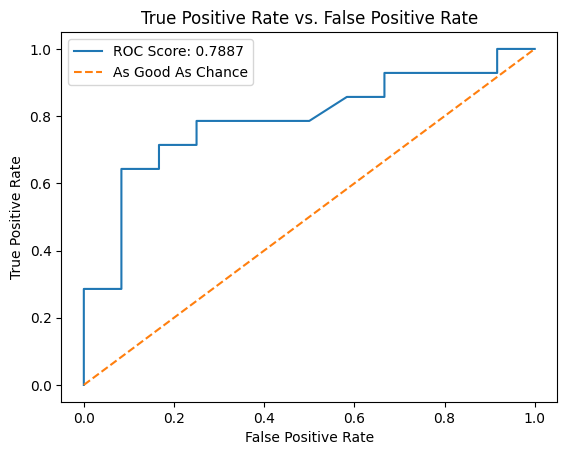

In [34]:
roc(y_proba=y_proba, y_test=y_test_rf)

In [35]:
space = {
    # 'booster': hp.choice('booster', ['gbtree']),
    # 'eta': hp.choice('eta', np.arange(0,1,.01)),
    # 'gamma': hp.choice('gamma', np.arange(1,1000,250)),
    # 'max_depth': hp.choice('max_depth', [6,8,10]),
    # 'subsample': hp.choice('subsample', [.5])
}

space = {
    'booster': hp.choice('booster', ['gblinear']),
    'reg_lambda': hp.choice('reg_lambda', np.arange(.0001, 100, 10)),
    'reg_alpha': hp.choice('reg_alpha', np.arange(.0001, 100, 10))
}

def hyperparameter_tuning(space):
    model = XGBClassifier(booster=space['booster'],
                          reg_lambda=space['reg_lambda'],
                          reg_alpha=space['reg_alpha'],
                          random_state=xgboost_seed
                          )
    # evaluation = [(X_train_gauss, y_train_gauss), (X_test_gauss, y_test_gauss)]

    model.fit(X_train_gauss_svc, y_train_gauss_svc)
    y_pred = model.predict(X_test_gauss_svc)
    acc = model.score(X_test_gauss_svc, y_test_gauss_svc)   
    print(f"Accuracy score: {acc}")

    print(f"Classification report:\n{classification_report(y_test_gauss_svc, y_pred)}")

    return {'loss': -acc, 'status': STATUS_OK}

In [36]:
trials = Trials()

best = fmin(fn=hyperparameter_tuning, space=space, algo=hyperopt.tpe.suggest, trials=trials, max_evals=100, verbose=0)

print(f"Best hyperparameter sweep: \n\t{best}")

Accuracy score: 0.6153846153846154
Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.62      1.00      0.76        16

    accuracy                           0.62        26
   macro avg       0.31      0.50      0.38        26
weighted avg       0.38      0.62      0.47        26

Accuracy score: 0.6153846153846154
Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.62      1.00      0.76        16

    accuracy                           0.62        26
   macro avg       0.31      0.50      0.38        26
weighted avg       0.38      0.62      0.47        26

Accuracy score: 0.6153846153846154
Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.62      1.00      0.76        16

    accu

In [37]:
xgboost = XGBClassifier(booster='gblinear', reg_lambda=.01, reg_alpha=100, random_state=xgboost_seed)
xgboost.fit(X_train_xgb, y_train_xgb)
y_pred = xgboost.predict(X_test_xgb)
y_proba = xgboost.predict_proba(X_test_xgb)
y_proba = y_proba[:,1]

print(classification_report(y_test_xgb, y_pred))

hyperopt_trained_models['XGBoost'] = xgboost

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.62      1.00      0.76        16

    accuracy                           0.62        26
   macro avg       0.31      0.50      0.38        26
weighted avg       0.38      0.62      0.47        26



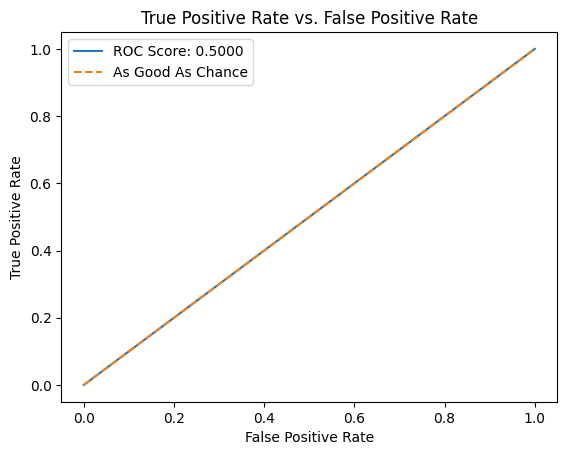

In [38]:
roc(y_proba=y_proba , y_test=y_test_xgb)

As of now, the models that are performing the best are the hyperparameter-tuned LinearSVC and GaussianNB models as well as the Hyperopt trained Random Forest Model. Although the LinearSVC model does not have a ROC Score attached to it the classification of both negative and positive classes are fairly strong (both ~ 80%).
* Below we will explore which features are needed with these three models

## Feature Selection

In [ ]:
final_models_dict = {
    'Random Forest': hyperopt_trained_models['Random Forest'],
    'Linear SVC': trained_models_dict['Linear SVC'],
    'Gaussian Naive-Bayes': trained_models_dict['gauss_nb']
}

In [59]:
from sklearn.feature_selection import RFE, RFECV

## Looping throught the hyperparameter-tuned models...
## this loop selects the model, uses the respective training and test sets to loop through the questions, starting with one,
## and then prints a classification report on each additional question

for name, model in final_models_dict.items():
    print(f"{'*'*30} {name} {'*'*30}")
    try:
        for i in range(1, X.shape[1]+1):
            print(f"{'*'*20} {i} feature(s) used {'*'*20}")
            
            if name == "Random Forest":
                selector = RFE(estimator=model, n_features_to_select=i, step=1)
                selector.fit(X_train_rf, y_train_rf)
                y_pred = selector.predict(X_test_rf)
                print(classification_report(y_test_rf, y_pred))
                # print(selector.ranking_)
            else:
                selector = RFE(estimator=model, n_features_to_select=i, step=1)
                selector.fit(X_train_gauss_svc, y_train_gauss_svc)
                y_pred = selector.predict(X_test_gauss_svc)
                print(classification_report(y_test_gauss_svc, y_pred))
                # print(selector.ranking_)
    except:
        print(f'Feature reduction cannot be utilized for {name}.')

****************************** Random Forest ******************************
******************** 1 feature(s) used ********************
              precision    recall  f1-score   support

           0       0.71      0.42      0.53        12
           1       0.63      0.86      0.73        14

    accuracy                           0.65        26
   macro avg       0.67      0.64      0.63        26
weighted avg       0.67      0.65      0.63        26

******************** 2 feature(s) used ********************
              precision    recall  f1-score   support

           0       0.56      0.42      0.48        12
           1       0.59      0.71      0.65        14

    accuracy                           0.58        26
   macro avg       0.57      0.57      0.56        26
weighted avg       0.57      0.58      0.57        26

******************** 3 feature(s) used ********************
              precision    recall  f1-score   support

           0       0.62      0.67  

The above classification reports show that using the Random Forest model with 5 questions or the Linear SVC model with 6 questions gives us the best macro average.

****************************** Random Forest ******************************
              precision    recall  f1-score   support

           0       0.71      0.42      0.53        12
           1       0.63      0.86      0.73        14

    accuracy                           0.65        26
   macro avg       0.67      0.64      0.63        26
weighted avg       0.67      0.65      0.63        26

Running total of importance: [5 2 4 3 1 6]
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.56      0.42      0.48        12
           1       0.59      0.71      0.65        14

    accuracy                           0.58        26
   macro avg       0.57      0.57      0.56        26
weighted avg       0.57      0.58      0.57        26

Running total of importance: [4 1 3 2 1 5]
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.62    

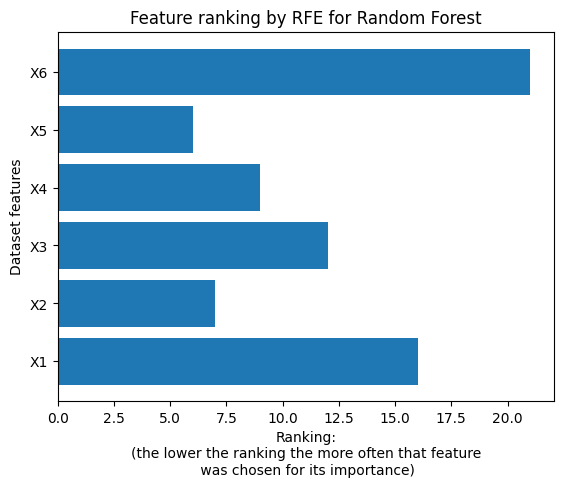

****************************** Linear SVC ******************************
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        10
           1       0.86      0.75      0.80        16

    accuracy                           0.77        26
   macro avg       0.76      0.78      0.76        26
weighted avg       0.78      0.77      0.77        26

Running total of importance: [1 6 3 4 2 5]
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.76      0.81      0.79        16

    accuracy                           0.73        26
   macro avg       0.72      0.71      0.71        26
weighted avg       0.73      0.73      0.73        26

Running total of importance: [1 5 2 3 1 4]
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.70      0

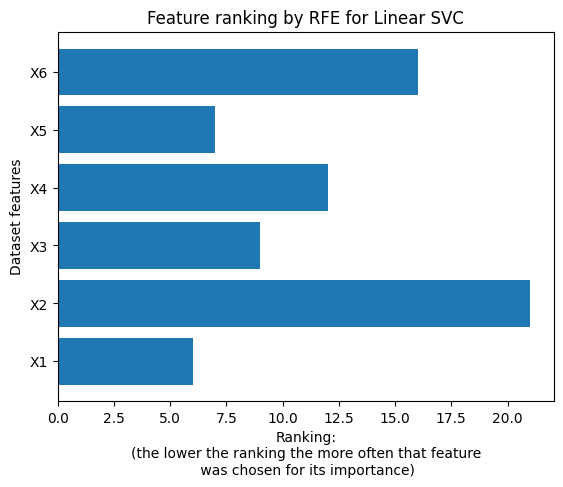

****************************** Gaussian Naive-Bayes ******************************
Feature reduction cannot be utilized for Gaussian Naive-Bayes


In [ ]:
## visualization of which questions each model is choosing for importance 

for name, model in final_models_dict.items():
    try:
        print(f"{'*'*30} {name} {'*'*30}")
        array = np.zeros(shape=(df.iloc[:, 1:].shape[1]))

        if name == "Random Forest":
            for i in range(1, X.shape[1]+1): #length of 6
                # for i in range(4,7):
                selector = RFE(estimator=model, n_features_to_select=i, step=1)
                selector.fit(X_train_rf, y_train_rf)
                y_pred = selector.predict(X_test_rf)
                print(classification_report(y_test_rf, y_pred))
                rank = np.array(selector.ranking_)
                print(f"Running total of importance: {rank}")
                array += rank
                print('-'*50)
            print(f"Final array of feature ranking values for {name}: {array}\n")

            plt.barh(y=X.columns, width=array)
            plt.title(f'Feature ranking by RFE for {name}')
            plt.xlabel('Ranking:\n(the lower the ranking the more often that feature\n was chosen for its importance)')
            plt.ylabel('Dataset features')
            plt.show()
        
        else:
            for i in range(1, X.shape[1]+1): #length of 6 (total questions in questionaire)
                # for i in range(4,7):
                selector = RFE(estimator=model, n_features_to_select=i, step=1)
                selector.fit(X_train_gauss_svc, y_train_gauss_svc)
                y_pred = selector.predict(X_test_gauss_svc)
                print(classification_report(y_test_gauss_svc, y_pred))
                rank = np.array(selector.ranking_)
                print(f"Running total of importance: {rank}")
                array += rank
                print('-'*50)
            print(f"Final array of feature ranking values for {name}: {array}\n")

            plt.barh(y=X.columns, width=array)
            plt.title(f'Feature ranking by RFE for {name}')
            plt.xlabel('Ranking:\n(the lower the ranking the more often that feature\n was chosen for its importance)')
            plt.ylabel('Dataset features')
            plt.show()

    except:
        print(f'Feature reduction cannot be utilized for {name}')

****************************** Random Forest ******************************
              precision    recall  f1-score   support

           0       0.60      0.50      0.55        12
           1       0.62      0.71      0.67        14

    accuracy                           0.62        26
   macro avg       0.61      0.61      0.61        26
weighted avg       0.61      0.62      0.61        26

Running total of importance: [2 1 1 1 1 3]
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.60      0.50      0.55        12
           1       0.62      0.71      0.67        14

    accuracy                           0.62        26
   macro avg       0.61      0.61      0.61        26
weighted avg       0.61      0.62      0.61        26

Running total of importance: [2 1 1 1 1 3]
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.60    

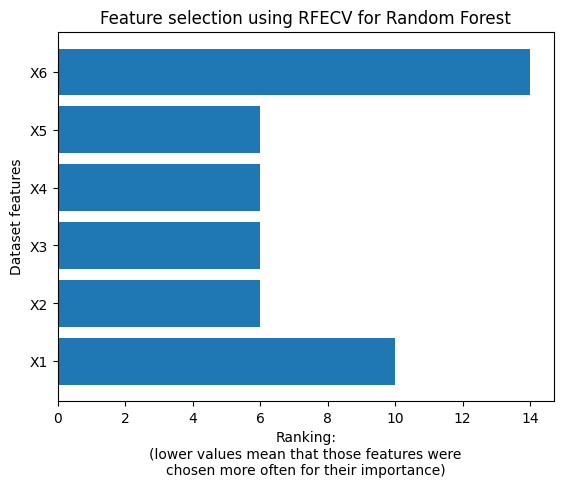

****************************** Linear SVC ******************************
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        10
           1       0.86      0.75      0.80        16

    accuracy                           0.77        26
   macro avg       0.76      0.78      0.76        26
weighted avg       0.78      0.77      0.77        26

Running total of importance: [1 6 3 4 2 5]
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.76      0.81      0.79        16

    accuracy                           0.73        26
   macro avg       0.72      0.71      0.71        26
weighted avg       0.73      0.73      0.73        26

Running total of importance: [1 3 1 1 1 2]
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.67      0

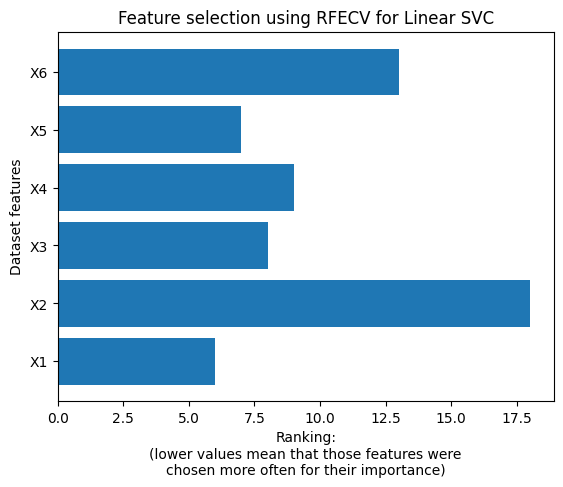

****************************** Gaussian Naive-Bayes ******************************
Feature reduction cannot be utilized for Gaussian Naive-Bayes


In [68]:
for name, model in final_models_dict.items():
    try:
        print(f"{'*'*30} {name} {'*'*30}")
        array_2 = np.zeros(shape=(df.iloc[:, 1:].shape[1]))

        if name == "Random Forest":
            for i in range(1, X.shape[1]+1):
                selector = RFECV(estimator=model, step=1, min_features_to_select=i, cv=5)
                selector.fit(X_train_rf, y_train_rf)
                y_pred = selector.predict(X_test_rf)

                print(classification_report(y_test_rf, y_pred))
                rank = np.array(selector.ranking_)    
                print(f"Running total of importance: {rank}")
                array_2 += rank
                print('-'*50)

            print(array_2)
            plt.barh(y=X.columns, width=array_2)
            plt.title(f'Feature selection using RFECV for {name}')
            plt.xlabel('Ranking:\n(lower values mean that those features were\nchosen more often for their importance)')
            plt.ylabel('Dataset features')
            plt.show()

        else:
            for i in range(1, X.shape[1]+1):
                selector = RFECV(estimator=model, step=1, min_features_to_select=i, cv=5)
                selector.fit(X_train_gauss_svc, y_train_gauss_svc)
                y_pred = selector.predict(X_test_gauss_svc)

                print(classification_report(y_test_gauss_svc, y_pred))
                rank = np.array(selector.ranking_)    
                print(f"Running total of importance: {rank}")
                array_2 += rank
                print('-'*50)

            print(array_2)
            plt.barh(y=X.columns, width=array_2)
            plt.title(f'Feature selection using RFECV for {name}')
            plt.xlabel('Ranking:\n(lower values mean that those features were\nchosen more often for their importance)')
            plt.ylabel('Dataset features')
            plt.show()

    except:
        print(f'Feature reduction cannot be utilized for {name}')

The two techniques used above show that if using the Random Forest model, question 6 is by far the least chosen feature in the dataset for its importance and question 1 is the second least chosen question. 

But if using the Linear SVC model we can see that question 2 and then question 6 are the least chosen questions.

#### Question 6 elimination AND question 6 and 1 elimination

Since we saw that the Random Forest model gave a satisfying macro score using only 5 questions (question 6 being the question selected the least using both methods) then we will test the model using only questions 1-5.

With the SVC model we saw that the model performed equally well using all 6 questions, but we will take out question 2 just to check if there is any difference.

In [ ]:
no_6_df = X[['X1' ,'X2' ,'X3', 'X4', 'X5']] ## mainly for Random Forest model
no_6_df.head()

,X1,X2,X3,X4,X5
0,3,3,3,4,2
1,3,2,3,5,4
2,5,3,3,3,3
3,5,4,3,3,3
4,5,4,3,3,3


In [ ]:
no_6_2_df = X[['X2', 'X3', 'X4', 'X5']] ## test for Random Forest model
no_6_2_df.head()

,X2,X3,X4,X5
0,3,3,4,2
1,2,3,5,4
2,3,3,3,3
3,4,3,3,3
4,4,3,3,3


In [71]:
no_2_df = X[['X1', 'X3', 'X4', 'X5', 'X6']] ## test for SVC model
no_2_df.head()

,X1,X3,X4,X5,X6
0,3,3,4,2,4
1,3,3,5,4,3
2,5,3,3,3,5
3,5,3,3,3,5
4,5,3,3,3,5


In [93]:
######## helper function for fitting the models on the new dataframes

def feature_extraction(df, target_variable, model, seed, title=None):
    X_train, X_test, y_train, y_test = train_test_split(df, target_variable, test_size=.20, random_state=seed)
    model_ = model
    model_.fit(X_train, y_train)
    y_preds = model_.predict(X_test)
    try:
        y_proba = model_.predict_proba(X_test)
        y_proba = y_proba[:,1]
    except:
        raise AttributeError('This model does not have this attribute')
    
    print(f"Classification report {title}:\n{classification_report(y_test, y_preds)}") if title is not None \
          else print(f"Classification report:\n{classification_report(y_test, y_preds)}")
    return y_proba, y_test
    

#### Linear SVC

In [94]:
## training/testing set with no question 2
X_train, X_test, y_train, y_test = train_test_split(no_2_df, target_variable, test_size=.20, random_state=svc_gauss_seed)

model = trained_models_dict['Linear SVC'].fit(X_train, y_train)
y_preds = model.predict(X_test)

print(f"Classification report with question 2 eliminated:\n{classification_report(y_test, y_preds)}\n")

linear_svc_model = LinearSVC(C=491, random_state=svc_gauss_seed)

linear_svc_model.fit(X_train_gauss_svc, y_train_gauss_svc)
y_pred = linear_svc_model.predict(X_test_gauss_svc)

print(f"Classification report with no questions eliminated:\n{classification_report(y_test_gauss_svc, y_pred)}")

Classification report with question 2 eliminated:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.81      0.81      0.81        16

    accuracy                           0.77        26
   macro avg       0.76      0.76      0.76        26
weighted avg       0.77      0.77      0.77        26


Classification report with no questions eliminated:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.87      0.81      0.84        16

    accuracy                           0.81        26
   macro avg       0.80      0.81      0.80        26
weighted avg       0.81      0.81      0.81        26



The elimination of questions 6 resulted in a slightly worse negative class recall score, and the elimination of both questions 1 and 6 resulted in worse recall scores for both classes.

You can see that the recall scores have not varied when dropping only question 4.

#### GaussianNB

In [84]:
# no_four_or_six = X[['X1', 'X2', 'X3', 'X5']]

In [100]:
gauss_nb = GaussianNB()

gauss_nb.fit(X_train_gauss_svc, y_train_gauss_svc)
y_pred = gauss_nb.predict(X_test_gauss_svc)

gauss_probs = gauss_nb.predict_proba(X_test_gauss_svc)
gauss_probs = gauss_probs[:, 1]

print(f"Classification report with stock model:\n{classification_report(y_test_gauss_svc, y_pred)}")

probs_5, test_5 = feature_extraction(no_6_df,
                                     target_variable,
                                     trained_models_dict['gauss_nb'],
                                     seed=svc_gauss_seed,
                                     title="with question 6 eliminated"
                                     )
probs_4, test_4 = feature_extraction(no_6_2_df,
                                     target_variable,
                                     trained_models_dict['gauss_nb'],
                                     seed=svc_gauss_seed,
                                     title="with questions 6 and 2 eliminated"
                                     )
probs_no_2, test_no_2 = feature_extraction(no_2_df,
                                           target_variable,
                                           trained_models_dict['gauss_nb'],
                                           seed=svc_gauss_seed,
                                           title="with question 2 eliminated"
                                           )
# probs_no_46, test_no_46 = feature_extraction(no_four_or_six, target_variable, trained_models_dict['gauss_nb'], seed=svc_gauss_seed)

Classification report with stock model:
              precision    recall  f1-score   support

           0       0.62      0.80      0.70        10
           1       0.85      0.69      0.76        16

    accuracy                           0.73        26
   macro avg       0.73      0.74      0.73        26
weighted avg       0.76      0.73      0.73        26

Classification report with question 6 eliminated:
              precision    recall  f1-score   support

           0       0.62      0.80      0.70        10
           1       0.85      0.69      0.76        16

    accuracy                           0.73        26
   macro avg       0.73      0.74      0.73        26
weighted avg       0.76      0.73      0.73        26

Classification report with questions 6 and 2 eliminated:
              precision    recall  f1-score   support

           0       0.43      0.60      0.50        10
           1       0.67      0.50      0.57        16

    accuracy                       

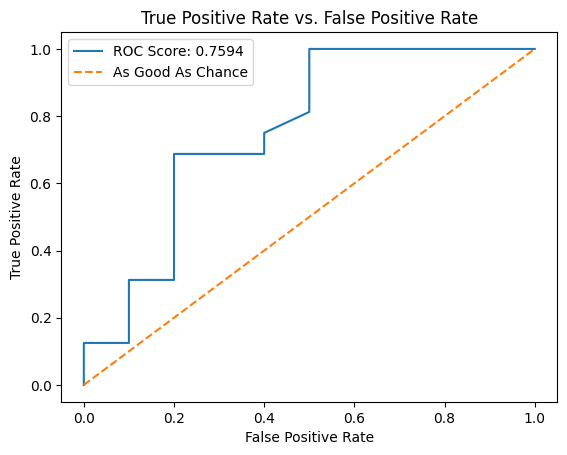

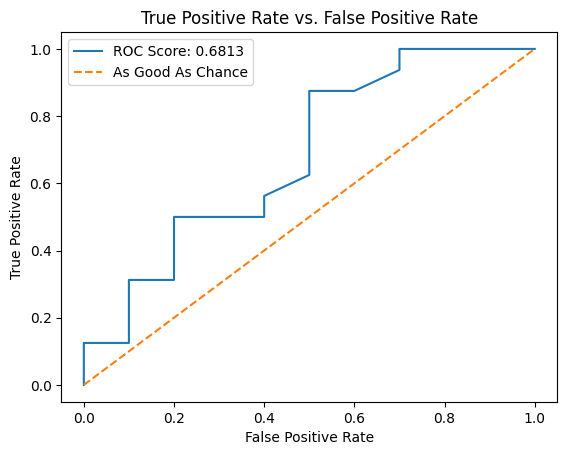

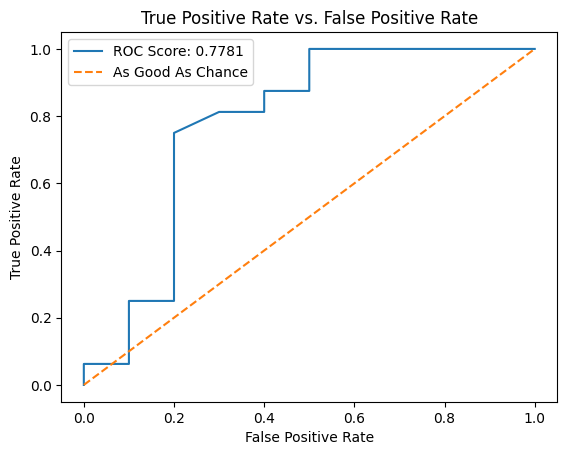

In [102]:
roc(y_proba=probs_5, y_test=test_5)
roc(probs_4, test_4)
roc(probs_no_2, test_no_2)

The GaussianNB model shows no signs of improvement when dropping any questions, specifically questions 6, 1, or 2.

#### Random Forest

In [106]:
rf_model = RandomForestClassifier(max_depth=6, max_features='sqrt', min_samples_split=2, n_estimators=1, random_state=rf_seed)

rf_model.fit(X_train_rf, y_train_rf)

y_preds = rf_model.predict(X_test_rf)
y_proba = rf_model.predict_proba(X_test_rf)

y_proba = y_proba[:, 1]

print(f"Classification report with hyperparameter-tuned Random Forest model:\n{classification_report(y_test_rf, y_preds)}")

probs_5, test_5 = feature_extraction(no_6_df,
                                     target_variable,
                                     hyperopt_trained_models['Random Forest'], 
                                     seed=rf_seed,
                                     title="with question 6 eliminated"
                                     )
probs_4, test_4 = feature_extraction(no_6_2_df,
                                     target_variable,
                                     hyperopt_trained_models['Random Forest'],
                                     seed=rf_seed,
                                     title="with questions 6 and 2 eliminated"
                                     )
probs_no_2, test_no_2 = feature_extraction(no_2_df,
                                           target_variable,
                                           hyperopt_trained_models['Random Forest'],
                                           seed=rf_seed,
                                           title="with question 2 eliminated"
                                           )

Classification report with hyperparameter-tuned Random Forest model:
              precision    recall  f1-score   support

           0       0.53      0.67      0.59        12
           1       0.64      0.50      0.56        14

    accuracy                           0.58        26
   macro avg       0.58      0.58      0.58        26
weighted avg       0.59      0.58      0.58        26

Classification report with question 6 eliminated:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85        12
           1       0.92      0.79      0.85        14

    accuracy                           0.85        26
   macro avg       0.85      0.85      0.85        26
weighted avg       0.86      0.85      0.85        26

Classification report with questions 6 and 2 eliminated:
              precision    recall  f1-score   support

           0       0.60      0.50      0.55        12
           1       0.62      0.71      0.67        14

    ac

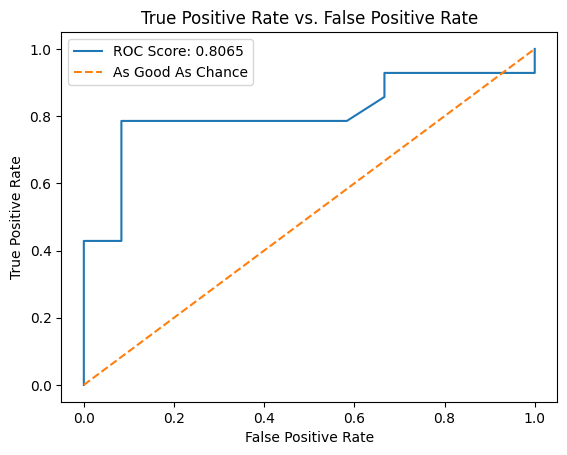

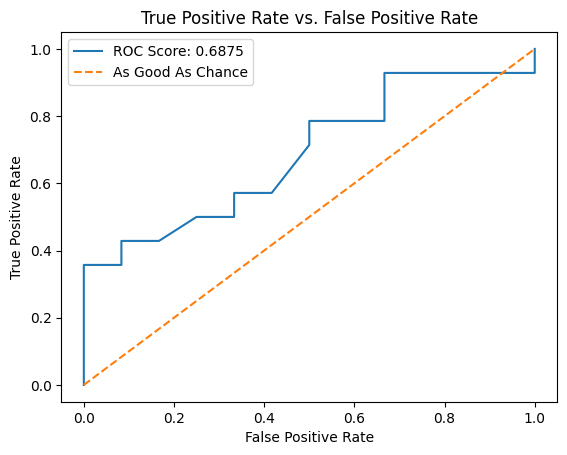

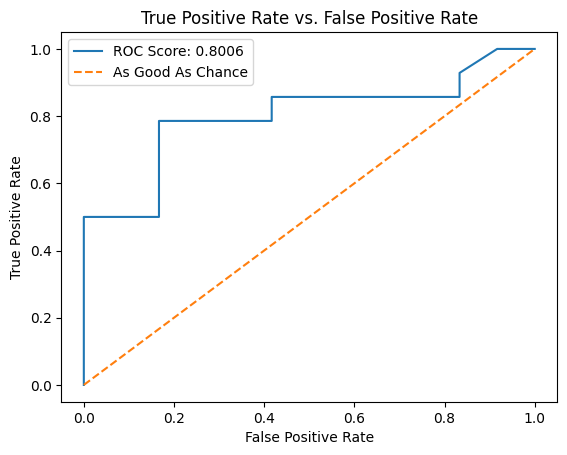

In [107]:
roc(probs_5, test_5)
roc(probs_4, test_4)
roc(probs_no_2, test_no_2)

The Random Forest model shows a slightly better ROC score when question 6 is eliminated versus when question 2 is eliminated.

The classification report shows that the macro average is slightly higher as well at 85%.

### Soft Voting Classifier

              precision    recall  f1-score   support

           0       0.58      0.47      0.52        15
           1       0.43      0.55      0.48        11

    accuracy                           0.50        26
   macro avg       0.51      0.51      0.50        26
weighted avg       0.52      0.50      0.50        26



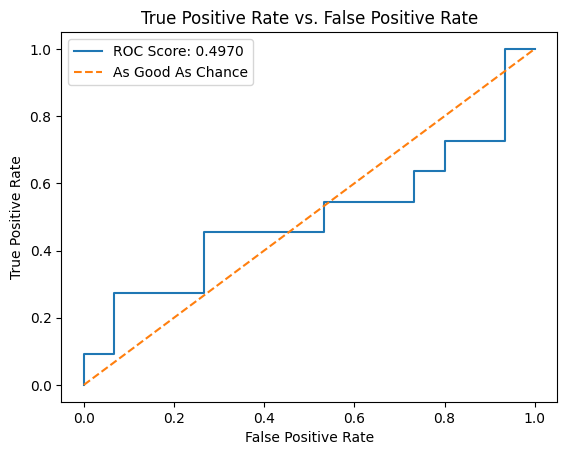

In [108]:
X_train, X_test, y_trian, y_test = train_test_split(no_6_df, target_variable, test_size=.20)

soft_vote_unfitted.fit(X_train, y_trian)

y_preds = soft_vote_unfitted.predict(X_test)
y_proba = soft_vote_unfitted.predict_proba(X_test)
y_proba = y_proba[:,1]

print(classification_report(y_test, y_preds))
roc(y_proba, y_test)

              precision    recall  f1-score   support

           0       0.40      0.57      0.47         7
           1       0.81      0.68      0.74        19

    accuracy                           0.65        26
   macro avg       0.61      0.63      0.61        26
weighted avg       0.70      0.65      0.67        26



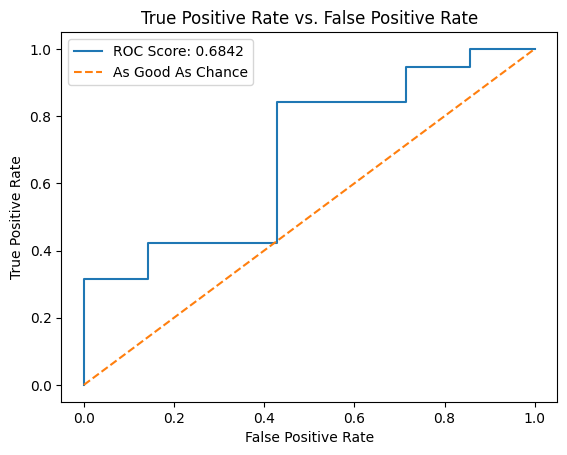

In [109]:
X_train, X_test, y_trian, y_test = train_test_split(no_2_df, target_variable, test_size=.20)

soft_vote_unfitted.fit(X_train, y_trian)

y_preds = soft_vote_unfitted.predict(X_test)
y_proba = soft_vote_unfitted.predict_proba(X_test)
y_proba = y_proba[:,1]

print(classification_report(y_test, y_preds))
roc(y_proba, y_test)

Just a quick reminder...

The columns used for this project were what follows

In [116]:
X.columns = columns
X.head()


,my order was delivered on time,contents of my order was as I expected,I ordered everything I wanted to order,I paid good price for my order,I am satisfied with my courier,the app makes ordering easy
0,3,3,3,4,2,4
1,3,2,3,5,4,3
2,5,3,3,3,3,5
3,5,4,3,3,3,5
4,5,4,3,3,3,5


With the elimination of certain questions from the questionaire we were able to gain a better understanding of what is making our customers satisfied or not.

Eliminating question 6 gave us a better recall rate with a Random Forest Model (~90% positive and ~79% negative).
Eliminating question 2 gave us a slightly worse score with the same model (~83% positive and ~79% negative).
Both ROC scores were around 80%.

## Conclusion

Using a Random Forest model with question 6 dropped from the survey looks to provide a better means of finding which customer are happy and which ones are not.